In [12]:
# === Cell 1: Configuration ===

import numpy as np

# --- Data paths (relative to this notebook) ---
DATA_DIR = "../Large Scale/bmDCA"
PF1 = "PF00004"                       # Protein family 1
PF2 = "PF00041"                       # Protein family 2

PARAMS_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_params.dat"
PARAMS_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_params.dat"
NAT_ENERGIES_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_naturalenergies.txt"
NAT_ENERGIES_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_naturalenergies.txt"

# --- Overlap length (nucleotides) ---
OVERLAP_LEN = 62

# --- Temperature grid (per-run coarse grid) ---
T1_MIN, T1_MAX, N_T1 = 0.45, 1.1, 10  # T1 grid for protein 1
T2_MIN, T2_MAX, N_T2 = 0.50, 1.15, 10  # T2 grid for protein 2

# --- Stagger parameters ---
N_STAGGER = 3     # offsets per dimension (N_STAGGER^2 runs per repeat)
N_REPEATS = 10     # independent repetitions for error bars
SEED_BASE = 42    # each run gets SEED_BASE + run_index

# --- 2D Replica Exchange MC parameters ---
RE2D_BURNIN         = 200_000   # Burn-in MC steps per replica
RE2D_SAMPLES        = 100_000     # Number of energy samples to collect
RE2D_SAMPLE_INTERVAL = 100      # MC steps between successive samples
RE2D_SWAP_INTERVAL   = 50       # MC steps between replica-swap attempts

# --- Z-score normalization ---
NAT_STD1 = 1.0                  # 1.0 = raw mode
NAT_STD2 = 1.0                  # 1.0 = raw mode

# --- Derived quantities ---
N_T1_FINE = N_T1 * N_STAGGER
N_T2_FINE = N_T2 * N_STAGGER
N_RUNS_PER_REPEAT = N_STAGGER ** 2
N_RUNS_TOTAL = N_RUNS_PER_REPEAT * N_REPEATS

print(f"Stagger design:")
print(f"  Per-run coarse grid: {N_T2}x{N_T1} = {N_T2*N_T1} replicas")
print(f"  Stagger offsets: {N_STAGGER} per dim -> {N_RUNS_PER_REPEAT} runs per repeat")
print(f"  Fine grid: {N_T2_FINE}x{N_T1_FINE} = {N_T2_FINE*N_T1_FINE} points")
print(f"  Repeats: {N_REPEATS} -> {N_RUNS_TOTAL} total runs")
print(f"  T1 range: [{T1_MIN}, {T1_MAX}], T2 range: [{T2_MIN}, {T2_MAX}]")

Stagger design:
  Per-run coarse grid: 10x10 = 100 replicas
  Stagger offsets: 3 per dim -> 9 runs per repeat
  Fine grid: 30x30 = 900 points
  Repeats: 10 -> 90 total runs
  T1 range: [0.45, 1.1], T2 range: [0.5, 1.15]


In [13]:
# === Cell 2: Data Loading & JIT Warmup ===

import sys, os, time

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from overlappingGenes import (
    extract_params, load_natural_energies, initial_seq_no_stops,
    seq_str_to_int_array, run_2d_replica_exchange
)

# Load DCA parameters
Js_1, hs_1 = extract_params(PARAMS_FILE_1)
Js_2, hs_2 = extract_params(PARAMS_FILE_2)
DCA_params_1 = [Js_1, hs_1]
DCA_params_2 = [Js_2, hs_2]

lenprot1 = len(hs_1) / 21
lenprot2 = len(hs_2) / 21
print(f"Protein 1 ({PF1}): {int(lenprot1)} AA, {int(3*lenprot1)} nt")
print(f"Protein 2 ({PF2}): {int(lenprot2)} AA, {int(3*lenprot2)} nt")
print(f"Overlap: {OVERLAP_LEN} nt")

# Load natural energies and compute stats
nat_energies_1 = np.array(load_natural_energies(NAT_ENERGIES_FILE_1))
nat_energies_2 = np.array(load_natural_energies(NAT_ENERGIES_FILE_2))
mean_1, std_1 = np.mean(nat_energies_1), np.std(nat_energies_1)
mean_2, std_2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"\nNatural energy stats:")
print(f"  {PF1}: mean={mean_1:.2f}, std={std_1:.2f} (n={len(nat_energies_1)})")
print(f"  {PF2}: mean={mean_2:.2f}, std={std_2:.2f} (n={len(nat_energies_2)})")

# JIT warmup: tiny 2x2 run to compile all numba functions
print("\nJIT warmup (2D RE)...")
t0 = time.time()
_ = run_2d_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP_LEN,
    T1_grid=np.array([0.5, 1.0]),
    T2_grid=np.array([0.5, 1.0]),
    n_burnin=50, n_samples=5, sample_interval=10,
    swap_interval=10,
    nat_std1=1.0, nat_std2=1.0
)
print(f"JIT warmup done in {time.time() - t0:.1f}s")

Protein 1 (PF00004): 110 AA, 330 nt
Protein 2 (PF00041): 74 AA, 222 nt
Overlap: 62 nt

Natural energy stats:
  PF00004: mean=145.88, std=38.25 (n=213960)
  PF00041: mean=120.66, std=17.64 (n=701132)

JIT warmup (2D RE)...
2D RE: 2x2 = 4 replicas
  T1 range: [0.500, 1.000]
  T2 range: [0.500, 1.000]
  Burn-in: 50, Samples: 5, Sample interval: 10, Swap interval: 10


2D RE: 100%|██████████| 100/100 [00:00<?, ?step/s]

2D RE completed in 0.00s (5 samples collected)
  Mean swap rate H: 0.333, V: 0.000
JIT warmup done in 0.0s


In [14]:
# === Cell 3: Run All Simulations ===

# Build fine grids
T1_fine = np.linspace(T1_MIN, T1_MAX, N_T1_FINE)
T2_fine = np.linspace(T2_MIN, T2_MAX, N_T2_FINE)

# Pre-allocate result arrays (filled with NaN for correctness check)
E1_all = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE, RE2D_SAMPLES), np.nan)
E2_all = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE, RE2D_SAMPLES), np.nan)
acc_all = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE), np.nan)

# Store per-run diagnostics
run_diagnostics = []

t_total = time.time()
run_count = 0

for r in range(N_REPEATS):
    for a in range(N_STAGGER):
        for b in range(N_STAGGER):
            run_idx = r * N_STAGGER**2 + a * N_STAGGER + b
            seed = SEED_BASE + run_idx
            run_count += 1

            # Extract coarse sub-grids for this run
            T1_sub = T1_fine[a::N_STAGGER]  # N_T1 points
            T2_sub = T2_fine[b::N_STAGGER]  # N_T2 points

            print(f"\n--- Run {run_count}/{N_RUNS_TOTAL} "
                  f"(repeat={r}, a={a}, b={b}, seed={seed}) ---")

            np.random.seed(seed)
            result = run_2d_replica_exchange(
                DCA_params_1, DCA_params_2,
                lenprot1, lenprot2, OVERLAP_LEN,
                T1_grid=T1_sub, T2_grid=T2_sub,
                n_burnin=RE2D_BURNIN, n_samples=RE2D_SAMPLES,
                sample_interval=RE2D_SAMPLE_INTERVAL,
                swap_interval=RE2D_SWAP_INTERVAL,
                nat_std1=NAT_STD1, nat_std2=NAT_STD2,
            )

            # Map coarse (i, j) -> fine grid indices
            for i in range(N_T2):
                for j in range(N_T1):
                    i_fine = b + i * N_STAGGER
                    j_fine = a + j * N_STAGGER
                    E1_all[r, i_fine, j_fine, :] = result['E1_grid'][i, j]
                    E2_all[r, i_fine, j_fine, :] = result['E2_grid'][i, j]
                    acc_all[r, i_fine, j_fine] = result['acceptance_grid'][i, j]

            # Store diagnostics
            mean_swap_h = np.mean(result['swap_rates_h'])
            mean_swap_v = np.mean(result['swap_rates_v'])
            run_diagnostics.append({
                'repeat': r, 'a': a, 'b': b, 'seed': seed,
                'mean_swap_h': mean_swap_h,
                'mean_swap_v': mean_swap_v,
                'mean_swap': (mean_swap_h + mean_swap_v) / 2,
                'elapsed': result['elapsed_time'],
            })

elapsed_total = time.time() - t_total

# Correctness check: every fine grid point must have been filled
assert not np.any(np.isnan(E1_all[:, :, :, 0])), "Some fine grid points were not filled!"
assert not np.any(np.isnan(E2_all[:, :, :, 0])), "Some fine grid points were not filled!"
assert not np.any(np.isnan(acc_all)), "Some acceptance grid points were not filled!"

print(f"\nAll {N_RUNS_TOTAL} runs completed in {elapsed_total:.1f}s")
print(f"Fine grid shape: E1_all = {E1_all.shape}")
swap_rates = [d['mean_swap'] for d in run_diagnostics]
print(f"Per-run mean swap rates: min={min(swap_rates):.3f}, "
      f"max={max(swap_rates):.3f}, mean={np.mean(swap_rates):.3f}")


--- Run 1/90 (repeat=0, a=0, b=0, seed=42) ---
2D RE: 10x10 = 100 replicas
  T1 range: [0.450, 1.055]
  T2 range: [0.500, 1.105]
  Burn-in: 200000, Samples: 100000, Sample interval: 100, Swap interval: 50


2D RE: 100%|██████████| 10200000/10200000 [01:56<00:00, 87767.86step/s]

2D RE completed in 116.22s (100000 samples collected)
  Mean swap rate H: 0.391, V: 0.489

--- Run 2/90 (repeat=0, a=0, b=1, seed=43) ---
2D RE: 10x10 = 100 replicas


  T1 range: [0.450, 1.055]
  T2 range: [0.522, 1.128]
  Burn-in: 200000, Samples: 100000, Sample interval: 100, Swap interval: 50


2D RE: 100%|██████████| 10200000/10200000 [01:56<00:00, 87624.83step/s]

...

2D RE completed in 113.45s (100000 samples collected)
  Mean swap rate H: 0.406, V: 0.487

--- Run 89/90 (repeat=9, a=2, b=1, seed=130) ---
2D RE: 10x10 = 100 replicas
  T1 range: [0.495, 1.100]
  T2 range: [0.522, 1.128]
  Burn-in: 200000, Samples: 100000, Sample interval: 100, Swap interval: 50



2D RE: 100%|██████████| 10200000/10200000 [01:50<00:00, 92315.55step/s]

2D RE completed in 110.49s (100000 samples collected)
  Mean swap rate H: 0.401, V: 0.497

--- Run 90/90 (repeat=9, a=2, b=2, seed=131) ---
2D RE: 10x10 = 100 replicas
  T1 range: [0.495, 1.100]
  T2 range: [0.545, 1.150]
  Burn-in: 200000, Samples: 100000, Sample interval: 100, Swap interval: 50



2D RE: 100%|██████████| 10200000/10200000 [01:51<00:00, 91579.63step/s]

2D RE completed in 111.38s (100000 samples collected)
  Mean swap rate H: 0.405, V: 0.508

All 90 runs completed in 10178.1s
Fine grid shape: E1_all = (10, 30, 30, 100000)
Per-run mean swap rates: min=0.433, max=0.458, mean=0.447


In [15]:
# === Cell 4: Compute Metrics ===

from scipy.stats import ks_2samp, wasserstein_distance
from tqdm import tqdm

# --- Z-score: fully vectorized, no loop needed ---
z_all = (np.mean(np.abs((E1_all - mean_1) / std_1), axis=-1)
       + np.mean(np.abs((E2_all - mean_2) / std_2), axis=-1))

# --- KS and Wasserstein: need per-point scipy calls ---
# Pre-sort natural energies once (saves re-sorting inside ks_2samp/wasserstein)
nat1_sorted = np.sort(nat_energies_1)
nat2_sorted = np.sort(nat_energies_2)

ks_all   = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE), np.nan)
wass_all = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE), np.nan)

total_pts = N_REPEATS * N_T2_FINE * N_T1_FINE
with tqdm(total=total_pts, desc="Computing KS/Wasserstein", unit="pt") as pbar:
    for r in range(N_REPEATS):
        for i in range(N_T2_FINE):
            for j in range(N_T1_FINE):
                e1 = E1_all[r, i, j]
                e2 = E2_all[r, i, j]

                ks1 = ks_2samp(nat1_sorted, e1).statistic
                ks2 = ks_2samp(nat2_sorted, e2).statistic
                ks_all[r, i, j] = (ks1 + ks2) / 2

                w1 = wasserstein_distance(nat1_sorted, e1)
                w2 = wasserstein_distance(nat2_sorted, e2)
                wass_all[r, i, j] = (w1 + w2) / 2

                pbar.update(1)

# Mean across repeats (for best-T identification)
ks_mean   = np.mean(ks_all, axis=0)
wass_mean = np.mean(wass_all, axis=0)
z_mean    = np.mean(z_all, axis=0)

# Std across repeats (for error bars when N_REPEATS > 1)
ks_std   = np.std(ks_all, axis=0) if N_REPEATS > 1 else None
wass_std = np.std(wass_all, axis=0) if N_REPEATS > 1 else None
z_std    = np.std(z_all, axis=0) if N_REPEATS > 1 else None

# --- Find best (T1, T2) per metric ---
def find_best(grid, T1_range, T2_range):
    idx = np.nanargmin(grid)
    i, j = np.unravel_index(idx, grid.shape)
    return T2_range[i], T1_range[j], grid[i, j], i, j

best_ks_T2,   best_ks_T1,   best_ks_val,   ki, kj = find_best(ks_mean,   T1_fine, T2_fine)
best_wass_T2, best_wass_T1, best_wass_val, wi, wj = find_best(wass_mean, T1_fine, T2_fine)
best_z_T2,    best_z_T1,    best_z_val,    zi, zj = find_best(z_mean,    T1_fine, T2_fine)

print(f"\nBest temperatures (fine grid):")
print(f"  KS:          T1={best_ks_T1:.4f}, T2={best_ks_T2:.4f} (KS={best_ks_val:.4f})")
print(f"  Wasserstein:  T1={best_wass_T1:.4f}, T2={best_wass_T2:.4f} (W={best_wass_val:.2f})")
print(f"  Z-score:      T1={best_z_T1:.4f}, T2={best_z_T2:.4f} (Z={best_z_val:.3f})")

if N_REPEATS > 1:
    print(f"\nMetric std at best-T (across {N_REPEATS} repeats):")
    print(f"  KS std:         {ks_std[ki, kj]:.4f}")
    print(f"  Wasserstein std: {wass_std[wi, wj]:.2f}")
    print(f"  Z-score std:     {z_std[zi, zj]:.3f}")

Computing KS/Wasserstein: 100%|██████████| 9000/9000 [20:50<00:00,  7.20pt/s]


Best temperatures (fine grid):
  KS:          T1=0.8534, T2=0.8810 (KS=0.0823)
  Wasserstein:  T1=0.8534, T2=0.8810 (W=6.52)
  Z-score:      T1=0.8534, T2=0.9034 (Z=1.190)

Metric std at best-T (across 10 repeats):
  KS std:         0.0072
  Wasserstein std: 0.66
  Z-score std:     0.011


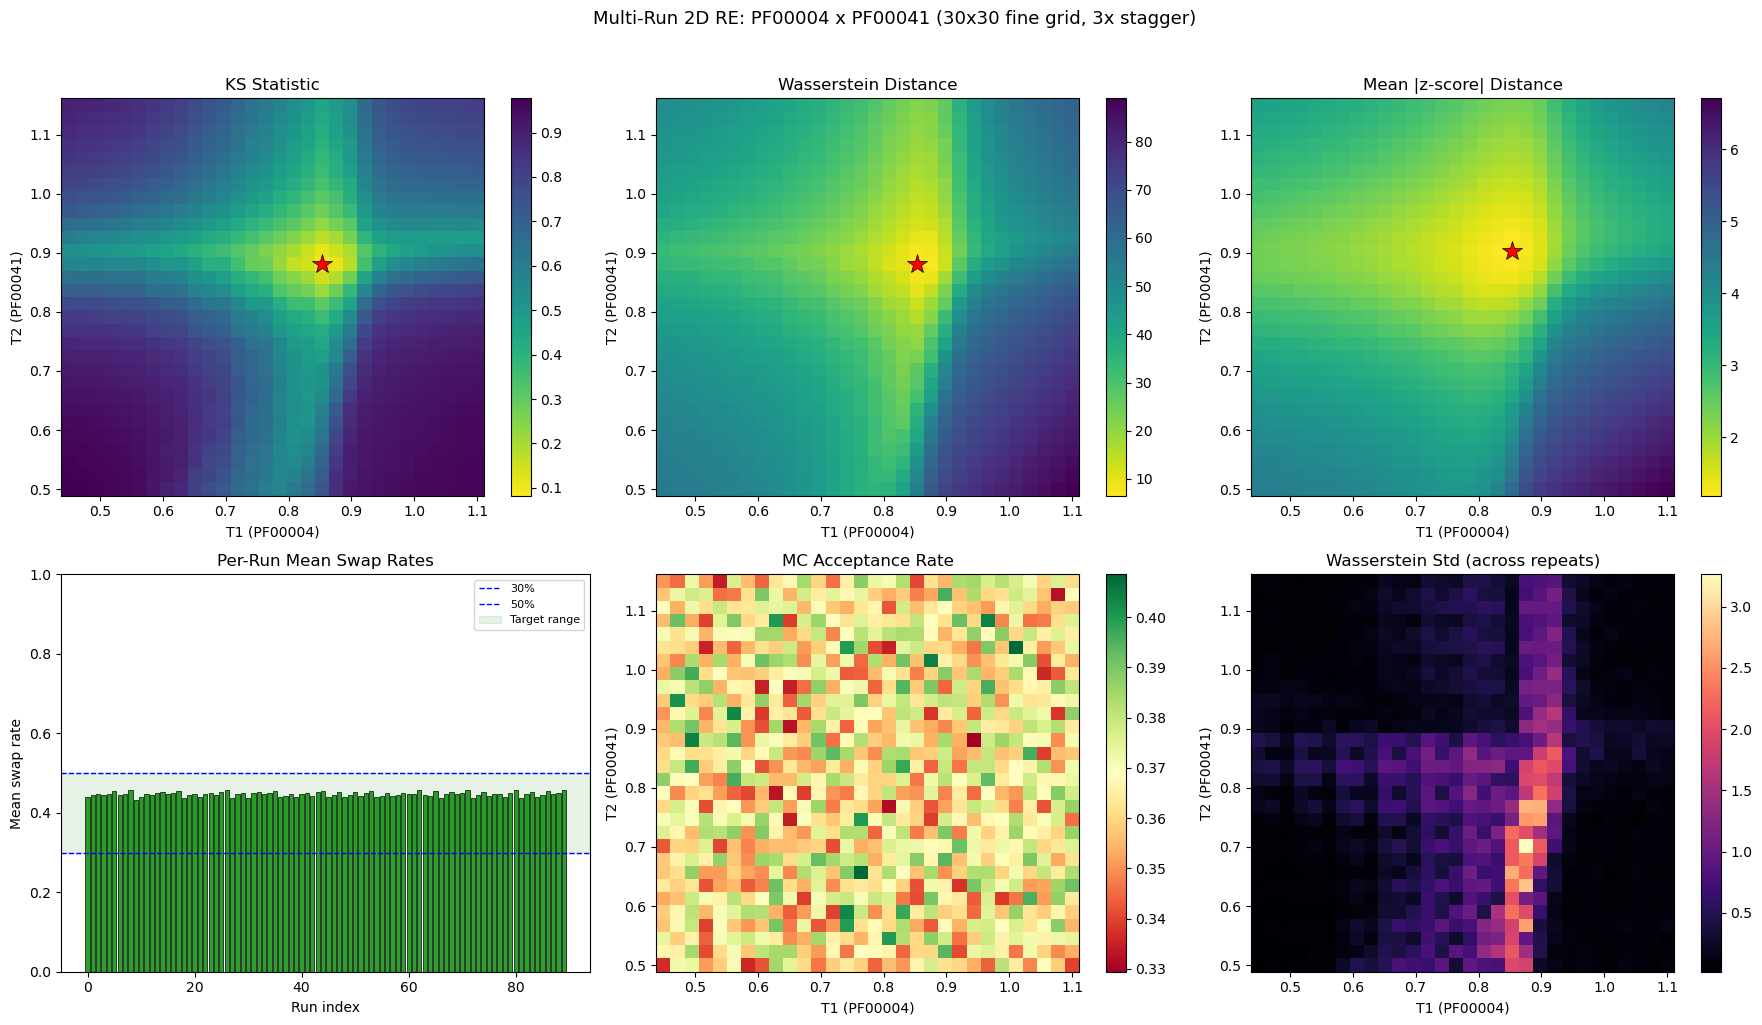

Saved re2d_multi_heatmaps.png


In [16]:
# === Cell 5: Heatmaps (raw fine grid) ===

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Top row: KS / Wasserstein / z-score on the fine grid ---
for ax, grid, title, (bT1, bT2) in zip(
    axes[0],
    [ks_mean, wass_mean, z_mean],
    ["KS Statistic", "Wasserstein Distance", "Mean |z-score| Distance"],
    [(best_ks_T1, best_ks_T2),
     (best_wass_T1, best_wass_T2),
     (best_z_T1, best_z_T2)]
):
    pcm = ax.pcolormesh(T1_fine, T2_fine, grid, cmap="viridis_r", shading="auto")
    ax.plot(bT1, bT2, "r*", markersize=15, markeredgecolor="k", markeredgewidth=0.5)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

# --- Bottom row ---
# (1) Bar chart of per-run mean swap rates
ax = axes[1, 0]
swap_rates_list = [d['mean_swap'] for d in run_diagnostics]
colors = ['#2ca02c' if 0.3 <= s <= 0.5 else '#d62728' if s < 0.2 or s > 0.7
          else '#ff7f0e' for s in swap_rates_list]
ax.bar(range(len(swap_rates_list)), swap_rates_list, color=colors, edgecolor='k', linewidth=0.5)
ax.axhline(0.3, color='blue', linestyle='--', linewidth=1, label='30%')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='50%')
ax.axhspan(0.3, 0.5, alpha=0.1, color='green', label='Target range')
ax.set_xlabel('Run index')
ax.set_ylabel('Mean swap rate')
ax.set_title('Per-Run Mean Swap Rates')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=8)

# (2) MC acceptance heatmap on fine grid
ax = axes[1, 1]
acc_mean = np.mean(acc_all, axis=0)
pcm = ax.pcolormesh(T1_fine, T2_fine, acc_mean, cmap="RdYlGn", shading="auto")
ax.set_xlabel(f"T1 ({PF1})")
ax.set_ylabel(f"T2 ({PF2})")
ax.set_title("MC Acceptance Rate")
fig.colorbar(pcm, ax=ax)

# (3) Wasserstein std heatmap if N_REPEATS > 1, else empty
ax = axes[1, 2]
if N_REPEATS > 1 and wass_std is not None:
    pcm = ax.pcolormesh(T1_fine, T2_fine, wass_std, cmap="magma", shading="auto")
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title("Wasserstein Std (across repeats)")
    fig.colorbar(pcm, ax=ax)
else:
    ax.text(0.5, 0.5, 'N_REPEATS=1\n(no std available)',
            transform=ax.transAxes, ha='center', va='center', fontsize=12)
    ax.set_title("Wasserstein Std")

fig.suptitle(f"Multi-Run 2D RE: {PF1} x {PF2} "
             f"({N_T2_FINE}x{N_T1_FINE} fine grid, {N_STAGGER}x stagger)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("re2d_multi_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_multi_heatmaps.png")

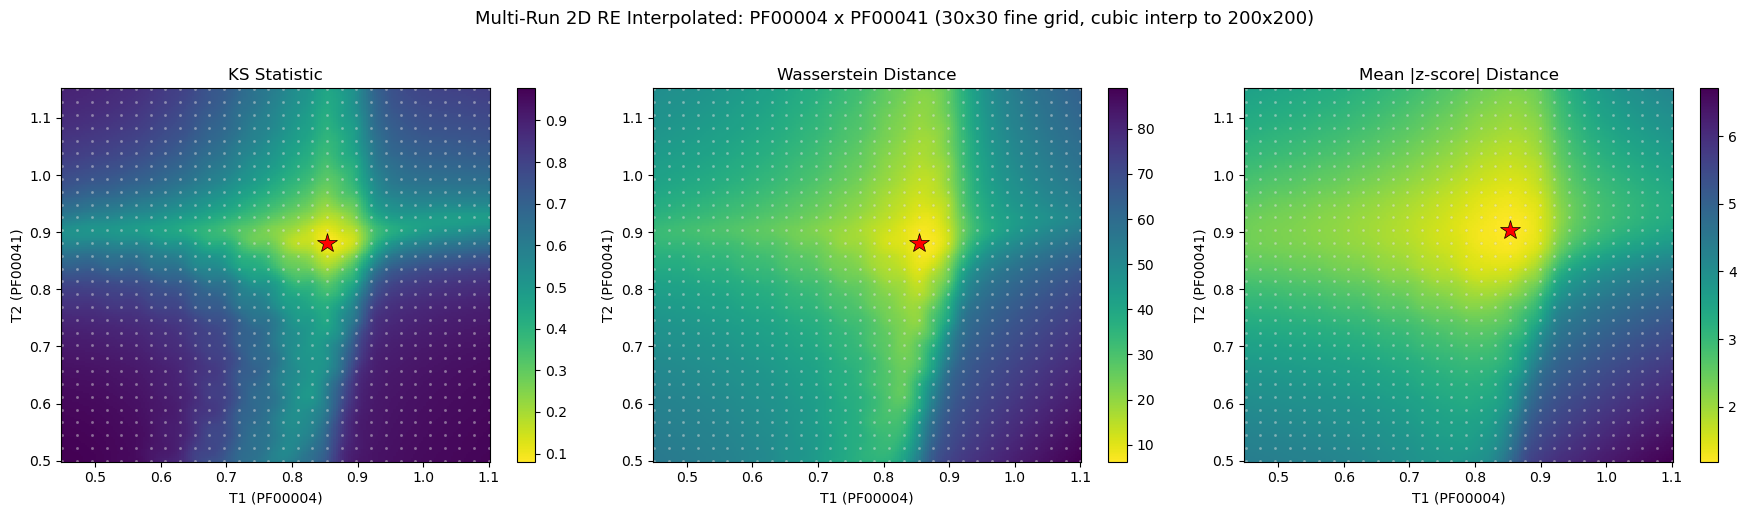

Saved re2d_multi_heatmaps_interpolated.png


In [17]:
# === Cell 6: Interpolated Heatmaps ===

from scipy.interpolate import RegularGridInterpolator

# Smooth grid for interpolation
T1_smooth = np.linspace(T1_MIN, T1_MAX, 200)
T2_smooth = np.linspace(T2_MIN, T2_MAX, 200)
T1_mesh, T2_mesh = np.meshgrid(T1_smooth, T2_smooth)
query_pts = np.column_stack([T2_mesh.ravel(), T1_mesh.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, grid, title, (bT1, bT2) in zip(
    axes,
    [ks_mean, wass_mean, z_mean],
    ["KS Statistic", "Wasserstein Distance", "Mean |z-score| Distance"],
    [(best_ks_T1, best_ks_T2),
     (best_wass_T1, best_wass_T2),
     (best_z_T1, best_z_T2)]
):
    interp = RegularGridInterpolator(
        (T2_fine, T1_fine), grid, method='cubic', bounds_error=False)
    grid_smooth = interp(query_pts).reshape(T2_mesh.shape)

    pcm = ax.pcolormesh(T1_smooth, T2_smooth, grid_smooth, cmap="viridis_r", shading="auto")
    # Overlay fine grid points as white dots
    T1_pts, T2_pts = np.meshgrid(T1_fine, T2_fine)
    ax.scatter(T1_pts.ravel(), T2_pts.ravel(), c='white', s=4, alpha=0.4,
               edgecolors='gray', linewidths=0.2)
    ax.plot(bT1, bT2, "r*", markersize=15, markeredgecolor="k", markeredgewidth=0.5)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

fig.suptitle(f"Multi-Run 2D RE Interpolated: {PF1} x {PF2} "
             f"({N_T2_FINE}x{N_T1_FINE} fine grid, cubic interp to 200x200)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("re2d_multi_heatmaps_interpolated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_multi_heatmaps_interpolated.png")

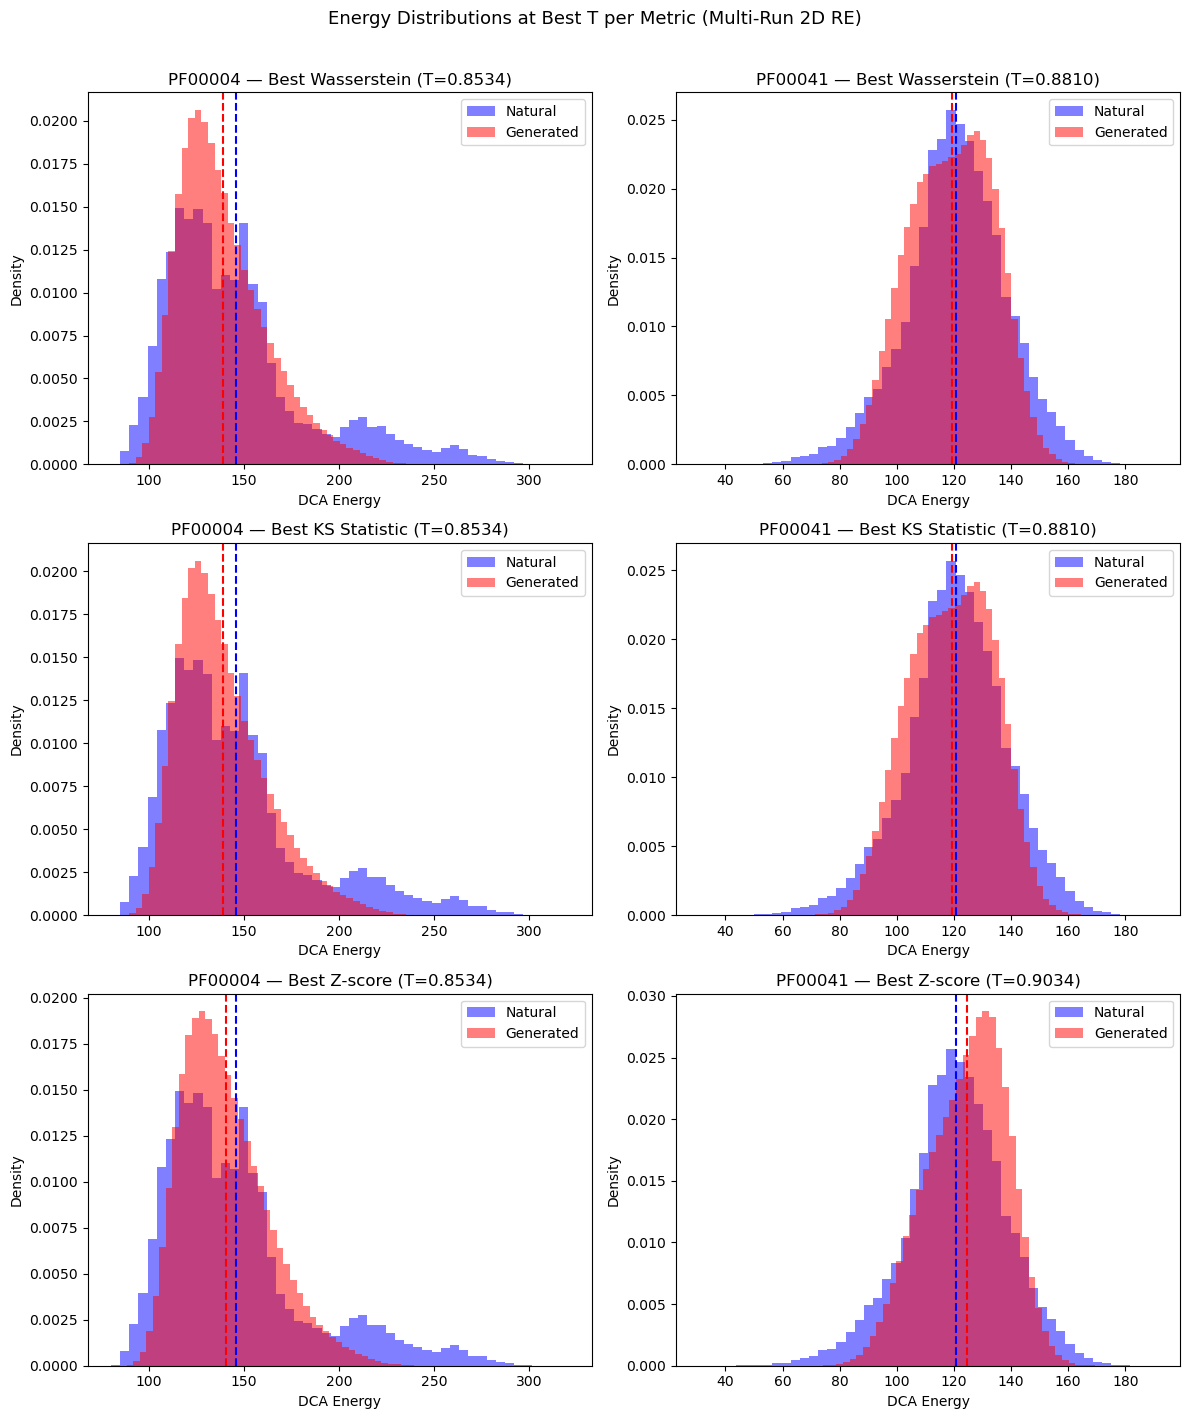

Saved re2d_multi_energy_histograms.png


In [18]:
# === Cell 7: Energy Histograms at Best T (all three metrics) ===

best_points = [
    ("Wasserstein", best_wass_T1, best_wass_T2, wi, wj, best_wass_val),
    ("KS Statistic", best_ks_T1, best_ks_T2, ki, kj, best_ks_val),
    ("Z-score", best_z_T1, best_z_T2, zi, zj, best_z_val),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for row, (metric_name, bT1, bT2, bi, bj, bval) in enumerate(best_points):
    # Concatenate samples across repeats for richer histograms
    if N_REPEATS > 1:
        E1_best = np.concatenate([E1_all[r, bi, bj] for r in range(N_REPEATS)])
        E2_best = np.concatenate([E2_all[r, bi, bj] for r in range(N_REPEATS)])
    else:
        E1_best = E1_all[0, bi, bj]
        E2_best = E2_all[0, bi, bj]

    for col, (nat_e, gen_e, pf, T_val) in enumerate([
        (nat_energies_1, E1_best, PF1, bT1),
        (nat_energies_2, E2_best, PF2, bT2),
    ]):
        ax = axes[row, col]
        ax.hist(nat_e, bins=50, density=True, alpha=0.5, color="blue", label="Natural")
        ax.hist(gen_e, bins=50, density=True, alpha=0.5, color="red", label="Generated")
        ax.axvline(np.mean(nat_e), color="blue", linestyle="--", linewidth=1.5)
        ax.axvline(np.mean(gen_e), color="red", linestyle="--", linewidth=1.5)
        ax.set_xlabel("DCA Energy")
        ax.set_ylabel("Density")
        ax.set_title(f"{pf} \u2014 Best {metric_name} (T={T_val:.4f})")
        ax.legend()

fig.suptitle(f"Energy Distributions at Best T per Metric (Multi-Run 2D RE)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig("re2d_multi_energy_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_multi_energy_histograms.png")

<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
C:\Users\orson\AppData\Local\Temp\ipykernel_30864\2213538553.py:57: SyntaxWarning: invalid escape sequence '\p'
  f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"


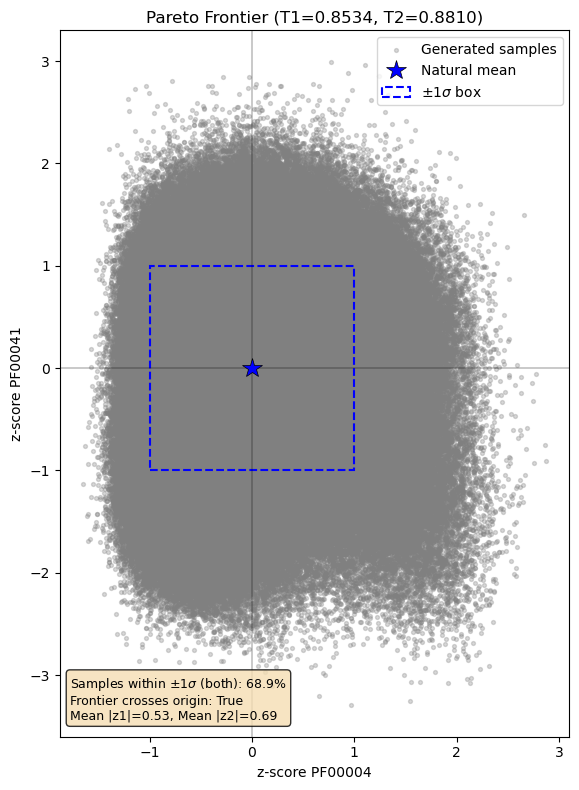

Saved re2d_multi_pareto_frontier.png


In [19]:
# === Cell 8: Pareto Frontier ===

# Use best Wasserstein fine-grid point
if N_REPEATS > 1:
    E1_pareto = np.concatenate([E1_all[r, wi, wj] for r in range(N_REPEATS)])
    E2_pareto = np.concatenate([E2_all[r, wi, wj] for r in range(N_REPEATS)])
else:
    E1_pareto = E1_all[0, wi, wj]
    E2_pareto = E2_all[0, wi, wj]

# Z-scores at best Wasserstein grid point
z1_det = (E1_pareto - mean_1) / std_1
z2_det = (E2_pareto - mean_2) / std_2

abs_z1 = np.abs(z1_det)
abs_z2 = np.abs(z2_det)

# Find Pareto frontier: non-dominated points in (|z1|, |z2|) space
sort_idx = np.argsort(abs_z1)
pareto_mask = np.zeros(len(z1_det), dtype=bool)
min_z2_so_far = np.inf
for k in sort_idx:
    if abs_z2[k] < min_z2_so_far:
        pareto_mask[k] = True
        min_z2_so_far = abs_z2[k]

pareto_abs_z1 = abs_z1[pareto_mask]
pareto_abs_z2 = abs_z2[pareto_mask]

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter all samples
ax.scatter(z1_det, z2_det, s=8, alpha=0.3, c="gray", label="Generated samples")

# Natural mean at origin
ax.plot(0, 0, "b*", markersize=15, markeredgecolor="k",
        markeredgewidth=0.5, zorder=5, label="Natural mean")

# +/- 1 sigma box
rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor="blue",
                      linestyle="--", linewidth=1.5, label=r"$\pm 1\sigma$ box")
ax.add_patch(rect)

ax.set_xlabel(f"z-score {PF1}")
ax.set_ylabel(f"z-score {PF2}")
ax.set_title(f"Pareto Frontier (T1={best_wass_T1:.4f}, T2={best_wass_T2:.4f})")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.axhline(0, color="k", linewidth=0.3)
ax.axvline(0, color="k", linewidth=0.3)

# Summary stats
within_1sigma = np.sum((abs_z1 <= 1) & (abs_z2 <= 1)) / len(z1_det) * 100
frontier_crosses = np.any((pareto_abs_z1 <= 0.1) & (pareto_abs_z2 <= 0.1))

stats_text = (
    f"Samples within $\pm 1\sigma$ (both): {within_1sigma:.1f}%\n"
    f"Frontier crosses origin: {frontier_crosses}\n"
    f"Mean |z1|={np.mean(abs_z1):.2f}, Mean |z2|={np.mean(abs_z2):.2f}"
)
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

fig.tight_layout()
fig.savefig("re2d_multi_pareto_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved re2d_multi_pareto_frontier.png")